In [1]:
!pip install sdv

In [7]:
import pandas as pd

In [12]:
real_data = pd.read_csv('vec21/odroid2_carbonyl_onscreen_VEC21.csv')
real_data.drop(['label'], axis=1, inplace=True)

In [13]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()

In [14]:
metadata.detect_from_dataframe(real_data)

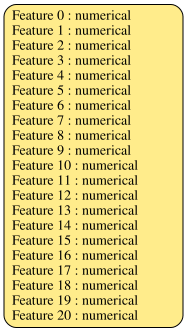

In [15]:
metadata.visualize()

In [16]:
from sdv.single_table import GaussianCopulaSynthesizer

synthesizer = GaussianCopulaSynthesizer(metadata, default_distribution='gaussian_kde')

/home/ai/miniconda3/lib/python3.11/site-packages/sdv/single_table/base.py:97: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [19]:
synthesizer.fit(
    data=real_data
)

In [20]:
synthetic_data = synthesizer.sample(
    num_rows=500
)

synthetic_data.head()

,Feature 0,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,...,Feature 11,Feature 12,Feature 13,Feature 14,Feature 15,Feature 16,Feature 17,Feature 18,Feature 19,Feature 20
0,90.1,88.7,86.9,85.8,85.2,85.1,85.1,85.4,85.2,85.1,...,85.4,85.6,85.8,85.7,86.4,85.0,85.5,85.5,85.5,85.1
1,91.1,86.2,86.2,84.8,84.8,84.9,85.1,85.3,84.9,85.0,...,85.1,85.3,85.2,85.3,85.4,84.9,85.0,85.1,85.8,85.2
2,89.9,87.0,86.4,85.1,84.7,85.3,85.0,84.6,84.7,84.9,...,85.1,85.0,84.8,85.5,84.7,85.2,85.2,85.4,84.9,85.0
3,91.9,90.5,87.0,85.7,85.5,85.7,85.0,85.2,85.3,85.6,...,85.1,86.0,87.3,86.2,110.6,85.4,86.3,85.5,86.0,85.4
4,89.1,86.2,85.9,85.1,84.8,85.1,84.6,84.5,84.7,84.7,...,84.4,84.8,84.8,84.4,84.5,84.4,84.8,85.1,84.4,84.6


In [21]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 5134.68it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |█████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 1375.63it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [22]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 1228.18it/s]|
Column Shapes Score: 84.06%

(2/2) Evaluating Column Pair Trends: |██████████████████████████████████████████████████████████████████████████████████████| 210/210 [00:00<00:00, 591.95it/s]|
Column Pair Trends Score: 89.14%

Overall Score (Average): 86.6%



In [23]:
quality_report.get_details('Column Shapes')

,Column,Metric,Score
0,Feature 0,KSComplement,0.833401
1,Feature 1,KSComplement,0.686507
2,Feature 2,KSComplement,0.860367
3,Feature 3,KSComplement,0.887621
4,Feature 4,KSComplement,0.865377
5,Feature 5,KSComplement,0.831701
6,Feature 6,KSComplement,0.886631
7,Feature 7,KSComplement,0.886379
8,Feature 8,KSComplement,0.839609
9,Feature 9,KSComplement,0.902703


In [60]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_name='Feature 10',
    metadata=metadata
)

fig.show()

In [24]:
synthetic_data.to_csv('synthetic_odroid2.csv', index=False)

In [28]:
synthesizer.get_parameters()

{'enforce_min_max_values': True,
 'enforce_rounding': True,
 'locales': ['en_US'],
 'numerical_distributions': {},
 'default_distribution': 'beta'}